In [8]:
import numpy as np

class MarketSimulator:
    def __init__(self, beta_matrix, competitor_designs, market_size):
       
        self.betas = beta_matrix
        self.comp_designs = competitor_designs
        self.market_size = market_size
        
        # Pre-calculate competitor utilities since they remain constant
        # Resulting matrix: (num_respondents, num_competitors)
        self.comp_utilities = np.dot(self.betas, self.comp_designs.T)

    def evaluate_product(self, our_design, our_price, our_cost, price_betas): #Setup main function with inputs expected 
        """
        Evaluates a new product configuration generated by NSGA-II.
        
        our_design: A 2D array of shape (1, num_attribute_levels)
        our_price: Float representing the product price
        our_cost: Float representing the product cost
        """
        # Calculate utility for our new product
        # Resulting matrix: (num_respondents, 1)
        feature_utility = np.dot(self.betas, our_design.T)

        #Adding Price negativity
        #price_betas shape: (num_respondents, 1)
        price_utilities = price_betas * our_price
        our_utility = feature_utility + price_utilities
        
        # Combine all utilities into a single matrix
        # Resulting matrix: (num_respondents, num_competitors + 1)
        all_utilities = np.hstack((self.comp_utilities, our_utility))
        
        # Apply Multinomial Logit (MNL) rule
        exp_utilities = np.exp(all_utilities)
        probabilities = exp_utilities / np.sum(exp_utilities, axis=1, keepdims=True)
        
        # Extract the probability column for our product (the last column)
        our_probabilities = probabilities[:, -1]
        
        # Calculate final objectives
        market_share = np.mean(our_probabilities)
        unit_sales = market_share * self.market_size
        profit = unit_sales * (our_price - our_cost)
        
        return market_share, profit

In [9]:
# --- Define product attributes here (edit this to change the product structure) ---
# Format: ("Attribute Name", number_of_levels)
attributes = [
    ("Wire Diameter", 3),   # e.g., 1.25mm, 2.00mm, 2.50mm
    ("Amperage",      2),   # e.g., 3A, 5A
    ("Cycles",        2),   # e.g., 50 cycles, 100 cycles
]

# Automatically derive everything else — DO NOT TOUCH !!!
num_levels     = [a[1] for a in attributes]
total_levels   = sum(num_levels)
start_indices  = [sum(num_levels[:i]) for i in range(len(num_levels))]

print(f"Attributes:             {[a[0] for a in attributes]}")
print(f"Levels per attribute:   {num_levels}")
print(f"Total one-hot columns:  {total_levels}")
print(f"Start index per attr:   {start_indices}")

# Dummy survey
np.random.seed(42) 
num_respondents = 100
dummy_betas = np.random.normal(loc=0.0, scale=1.5, size=(num_respondents, total_levels))

market_size = int(input("Enter the total market size (e.g., 50000): "))
our_price = float(input("Enter our product price in dollars (e.g., 2.50): "))
our_cost = float(input("Enter our product unit cost in dollars (e.g., 0.85): "))

# Generate negative price sensitivities for 100 respondents
# Average sensitivity is -0.8 utility points per dollar
price_betas = np.random.normal(loc=-0.8, scale=0.2, size=(num_respondents, 1))

# Competitor data manually defined, update columns to match your attributes) #Automate
# Define competitor prices
# Competitor A ($2.00) and Competitor B ($3.50)
comp_prices = np.array([[2.00], [3.50]]) #Automate

# Competitor A: 1.25mm, 3A, 50 cycles  -> [1, 0, 0,  1, 0,  1, 0]
# Competitor B: 2.50mm, 5A, 100 cycles -> [0, 0, 1,  0, 1,  0, 1]
competitor_matrix = np.array([
    [1, 0, 0, 1, 0, 1, 0],
    [0, 0, 1, 0, 1, 0, 1]
])

# Initialize the Simulator
simulator = MarketSimulator(dummy_betas, competitor_matrix, market_size)
# Update the competitor utility calculation to include their prices
# (num_respondents, num_competitors) + (num_respondents, 1) * (1, num_competitors)
simulator.comp_utilities += np.dot(price_betas, comp_prices.T)
# Our Product: 2.00mm, 5A, 50 cycles -> [0, 1, 0,  0, 1,  1, 0]
our_new_design = np.array([[0, 1, 0, 0, 1, 1, 0]]) 

# Running the evaluation
market_share, profit = simulator.evaluate_product(our_new_design, our_price, our_cost, price_betas)

# Output
print(f"Product Design String: {our_new_design[0]}")
print(f"Price: ${our_price:.2f} | Cost: ${our_cost:.2f}")
print(f"Calculated Market Share: {market_share * 100:.2f}%")
print(f"Projected Profit: ${profit:,.2f}")

Attributes:             ['Wire Diameter', 'Amperage', 'Cycles']
Levels per attribute:   [3, 2, 2]
Total one-hot columns:  7
Start index per attr:   [0, 3, 5]


Enter the total market size (e.g., 50000):  50000
Enter our product price in dollars (e.g., 2.50):  3
Enter our product unit cost in dollars (e.g., 0.85):  0.7


Product Design String: [0 1 0 0 1 1 0]
Price: $3.00 | Cost: $0.70
Calculated Market Share: 29.81%
Projected Profit: $34,286.50


In [11]:
from pymoo.core.problem import ElementwiseProblem
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.optimize import minimize
import numpy as np

class Optimizer(ElementwiseProblem):
    def __init__(self, sim, price_betas, attributes):
        
        # Derive structure from attributes
        self.num_levels    = [a[1] for a in attributes]
        self.total_levels  = sum(self.num_levels)
        self.start_indices = [sum(self.num_levels[:i]) for i in range(len(self.num_levels))]
        self.sim           = sim
        self.price_betas   = price_betas

        # Build bounds dynamically
        # Each attribute variable ranges from 0 to (num_levels - 1)
        # Price is always the last variable, ranging from $1.00 to $5.00
        lower = np.array([0          for n in self.num_levels] + [1.0])
        upper = np.array([n - 1      for n in self.num_levels] + [5.0])

        super().__init__(n_var=len(attributes) + 1, n_obj=2, xl=lower, xu=upper)

    def _evaluate(self, x, out, *args, **kwargs):
        
        # Build the one-hot design vector dynamically
        design = np.zeros((1, self.total_levels))
        
        for i, start in enumerate(self.start_indices):
            chosen_level = int(round(x[i]))
            design[0, start + chosen_level] = 1

        price = x[-1]  # price is always the last variable

        share, profit = self.sim.evaluate_product(design, price, 0.85, self.price_betas)
        out["F"] = [-share, -profit]

# --- Execute and Print ---
res = minimize(Optimizer(simulator, price_betas, attributes), NSGA2(pop_size=100), ('n_gen', 1000))

print(f"Found {len(res.F)} optimal solutions:\n" + "-"*45)

for share, profit, price in zip(-res.F[:, 0], -res.F[:, 1], res.X[:, len(attributes)]):
    print(f"Share: {share*100:5.2f}% | Profit: ${profit:8.2f} | Price: ${price:5.2f}")

Found 100 optimal solutions:
---------------------------------------------
Share: 23.62% | Profit: $35068.20 | Price: $ 3.82
Share: 55.03% | Profit: $ 4126.95 | Price: $ 1.00
Share: 23.62% | Profit: $35068.20 | Price: $ 3.82
Share: 55.03% | Profit: $ 4126.95 | Price: $ 1.00
Share: 35.52% | Profit: $28914.02 | Price: $ 2.48
Share: 32.90% | Profit: $31336.48 | Price: $ 2.75
Share: 30.74% | Profit: $32870.98 | Price: $ 2.99
Share: 42.90% | Profit: $22778.34 | Price: $ 1.91
Share: 31.75% | Profit: $32205.14 | Price: $ 2.88
Share: 42.22% | Profit: $23485.45 | Price: $ 1.96
Share: 25.62% | Profit: $34894.31 | Price: $ 3.57
Share: 24.77% | Profit: $35010.50 | Price: $ 3.68
Share: 48.79% | Profit: $15247.89 | Price: $ 1.48
Share: 51.10% | Profit: $11533.58 | Price: $ 1.30
Share: 47.90% | Profit: $16551.94 | Price: $ 1.54
Share: 43.71% | Profit: $21898.87 | Price: $ 1.85
Share: 26.38% | Profit: $34736.72 | Price: $ 3.48
Share: 39.92% | Profit: $25626.94 | Price: $ 2.13
Share: 40.39% | Profit: $

In [ ]:
from pymoo.core.problem import ElementwiseProblem
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.optimize import minimize
import numpy as np

class Optimizer(ElementwiseProblem):
    def __init__(self, sim, price_betas, attributes):
        self.num_levels    = [a[1] for a in attributes]
        self.total_levels  = sum(self.num_levels)
        self.start_indices = [sum(self.num_levels[:i]) for i in range(len(self.num_levels))]
        self.sim           = sim
        self.price_betas   = price_betas

        lower = np.array([0      for n in self.num_levels] + [1.0])
        upper = np.array([n - 1  for n in self.num_levels] + [5.0])

        super().__init__(n_var=len(attributes) + 1, n_obj=2, xl=lower, xu=upper) 

    def _evaluate(self, x, out, *args, **kwargs):
        design = np.zeros((1, self.total_levels))
        
        for i, start in enumerate(self.start_indices):
            chosen_level = int(round(x[i]))
            design[0, start + chosen_level] = 1

        price = x[-1]

        share, profit = self.sim.evaluate_product(design, price, 0.85, self.price_betas)
        out["F"] = [-share, -profit]

# --- Execute and Print ---
res = minimize(Optimizer(simulator, price_betas, attributes), NSGA2(pop_size=200), ('n_gen', 10000))

print(f"Found {len(res.F)} optimal solutions:\n" + "-"*45)

for share, profit, price in zip(-res.F[:, 0], -res.F[:, 1], res.X[:, 3]):
    print(f"Share: {share*100:5.2f}% | Profit: ${profit:8.2f} | Price: ${price:5.2f}")

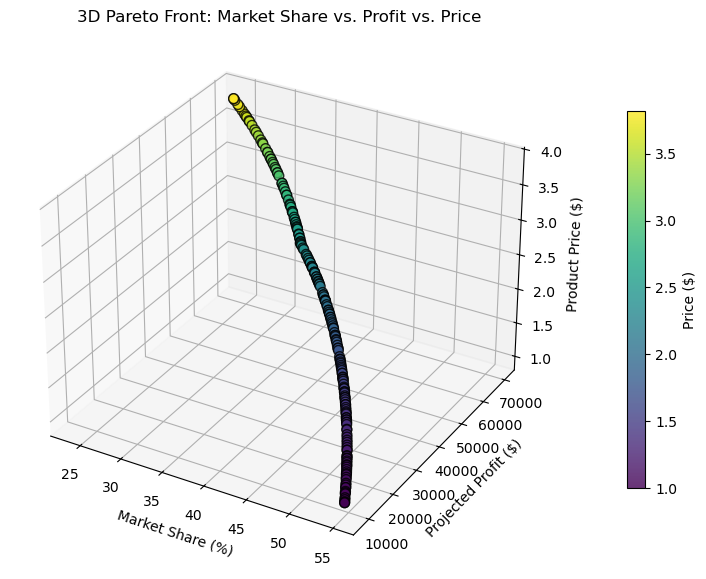

In [7]:
import matplotlib.pyplot as plt

# Extract the final values from your Pymoo results
market_share = -res.F[:, 0] * 100
profit = -res.F[:, 1]
prices = res.X[:, len(attributes)]

# Set up the 3D figure
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# Create the 3D scatter plot
# Using a subtle color gradient along the Z-axis (price) for extra clarity
scatter = ax.scatter(market_share, profit, prices, c=prices, cmap='viridis', s=50, alpha=0.8, edgecolors='black')

# Add professional labels and formatting
ax.set_title("3D Pareto Front: Market Share vs. Profit vs. Price")
ax.set_xlabel("Market Share (%)")
ax.set_ylabel("Projected Profit ($)")
ax.set_zlabel("Product Price ($)")

# Add a color bar legend for the exact price values
cbar = fig.colorbar(scatter, ax=ax, pad=0.1, shrink=0.7)
cbar.set_label("Price ($)")

# Display the interactive 3D graph
plt.show()